In [39]:
import numpy as np
# import sympy as sp
from plotly import express as px
from matplotlib import pyplot as plt
import pandas as pd
import scipy as scp


#IGUAL PARA TODOS LOS EXPERIMENTOS AL MENOS DEL MIERCOLES PASADO QSY NO CREO QUE NADIE VAYA A LEER ESTO HOLA CUCHU

V1=pd.read_csv('V_1.csv')
V2=pd.read_csv('V_2.csv')
V3=pd.read_csv('V_3.csv')
V4=pd.read_csv('V_4.csv')[2:7]
V5a=pd.read_csv('V_5_ascensor.csv')
V5o=pd.read_csv('V_5_octogono.csv')

lista=[V1,V2,V3,V4,V5a,V5o]


In [40]:
V1['d']*=1e-2
V2['d']*=1e-2

In [20]:
Vtot=pd.concat([V1,V2,V3,V4,V5a],ignore_index=True)
Vtot=Vtot.sort_values(by=['d'])
Vtot
d=Vtot['d']
V=Vtot['V']

In [21]:
#########FUNCIONES

def funkfit (x,a,b,c,d):
    """ a*np.sin(2 pi* b * x + c )+d """
    return a*np.sin(2*np.pi*b*x+c)+d

def B_short(x,n,a,log=False):
    if log:
        return np.exp(a)*x**n
    else:    
        return a*x**n

def lock_in(datos,f):
    x,y =datos['Second'],datos['Volt.1']
    
    # print(x,'\n',y)
    dx=x.iloc[-1]-x.iloc[0]
    
    y_cos= np.cos(2*np.pi*f*x)* y
    y_sin= np.sin(2*np.pi*f*x)* y

    U_cos=1/dx*np.trapz(y_cos,x=x)
    U_sin=1/dx*np.trapz(y_sin,x=x)

    
    # plt.figure()
    # plt.plot(y_cos)
    r=((2*U_cos)**2+(2*U_sin)**2)**.5
    phi=np.arctan2(U_sin,U_cos)

    return r,phi

Text(0, 0.5, 'Voltaje [V]')

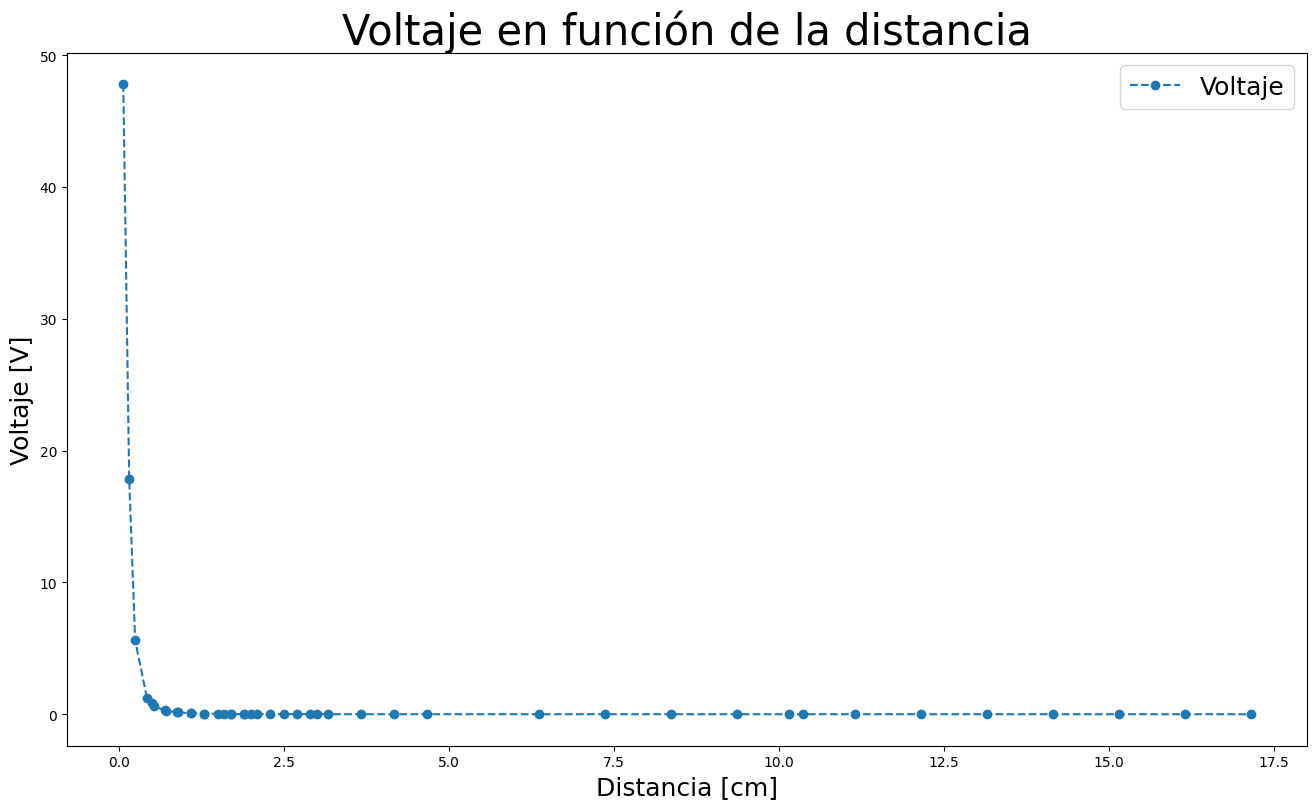

In [22]:
plt.figure(figsize=(16,9))
plt.plot(d,V,'o--')

plt.title('Voltaje en función de la distancia',fontsize=30)
plt.legend(['Voltaje'],fontsize=18)

plt.xlabel('Distancia [cm]',fontsize=18)
plt.ylabel('Voltaje [V]',fontsize=18)

In [23]:
cutinf=2
cuthigh=len(V)
#n=8
# dtest=list(d[:n])+list(d[n+1:])
# vtest=list(V[:n])+list(V[n+1:])
P=np.polyfit(np.log(d[cutinf:cuthigh]),np.log(V[cutinf:cuthigh]),1)
# P=np.polyfit(np.log(dtest),np.log(vtest),1)

#P=np.polyfit(np.log(distd2[1:-1]),np.log(V2[1:-1]),1)
P

array([-3.03421253, -2.31663068])

Text(0, 0.5, 'Voltaje [V]')

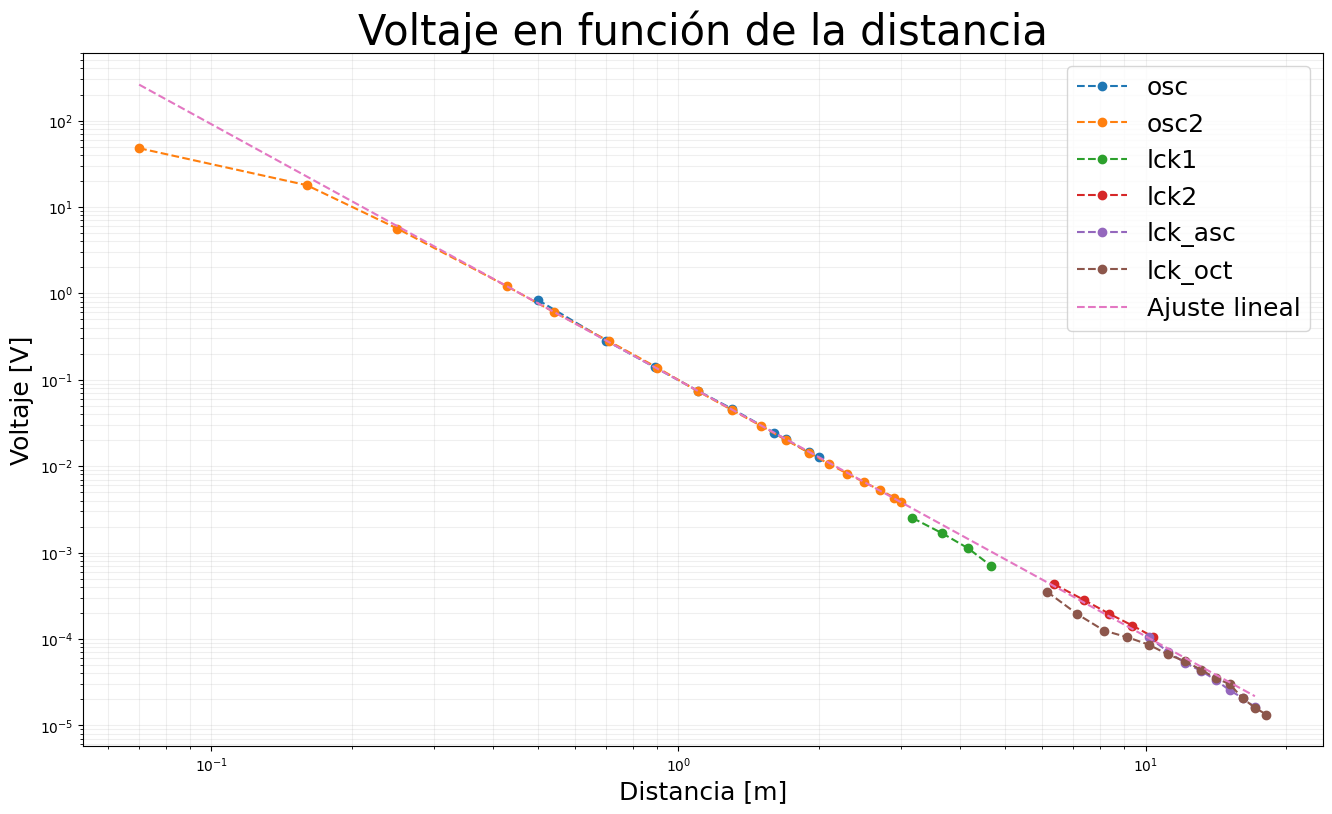

In [ ]:
plt.figure(figsize=(16,9))
for j,i in enumerate(lista):
    if j!=4:
        plt.loglog(i['d'],i['V'],'o--')
    else:
        plt.loglog(i['d'],i['V']*1.1521739130434783,'o--') # x otaduy

plt.loglog(d,B_short(d,*P,log=True),'--')
plt.title('Voltaje en función de la distancia',fontsize=30)
plt.legend(['osc','osc2','lck1','lck2','lck_asc','lck_oct','Ajuste lineal'],fontsize=18)
plt.grid(which='both',alpha=0.2)
plt.xlabel('Distancia [m]',fontsize=18)
plt.ylabel('Voltaje [V]',fontsize=18)

Text(0, 0.5, 'Voltaje [V]')

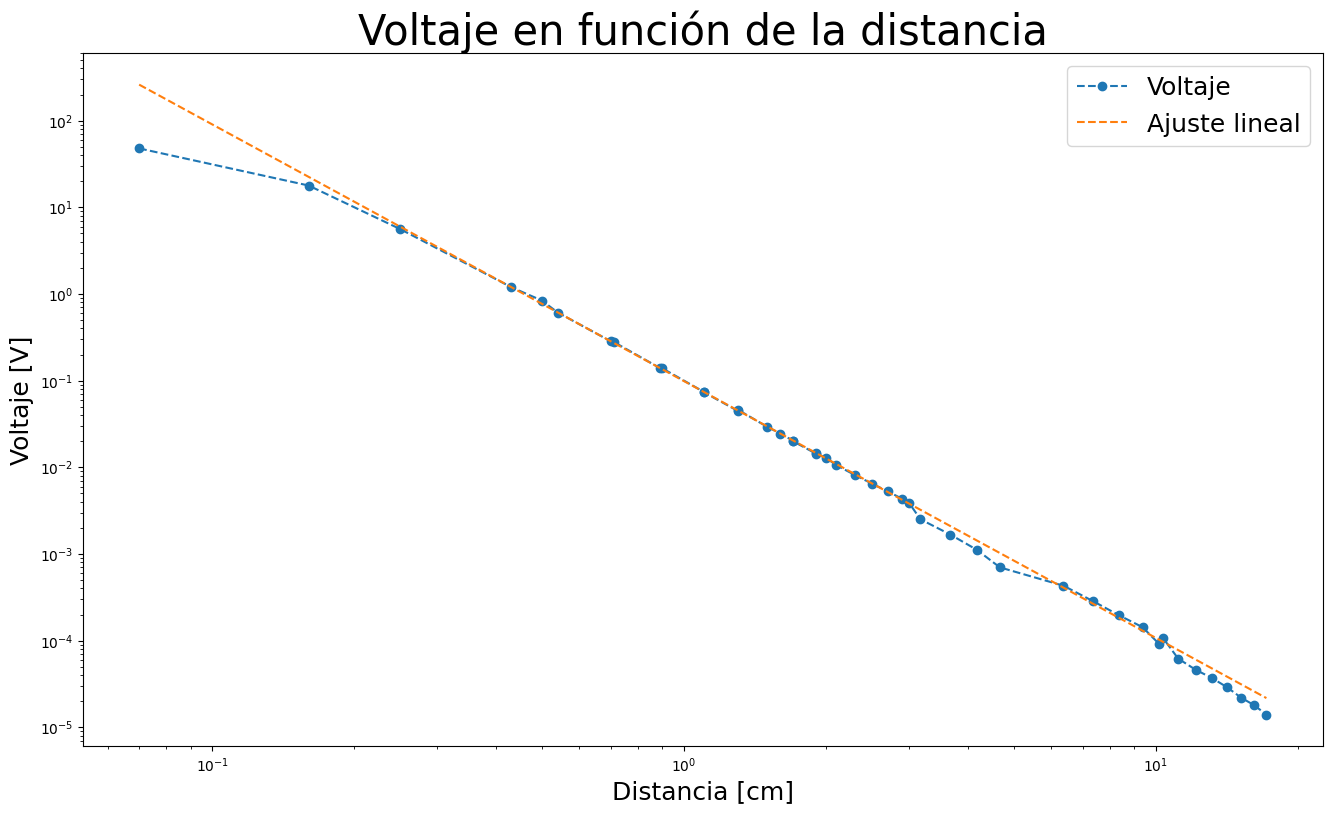

In [37]:
plt.figure(figsize=(16,9))
plt.loglog(d,V,'o--')
plt.loglog(d,B_short(d,*P,log=True),'--')
plt.title('Voltaje en función de la distancia',fontsize=30)
plt.legend(['Voltaje','Ajuste lineal'],fontsize=18)

plt.xlabel('Distancia [cm]',fontsize=18)
plt.ylabel('Voltaje [V]',fontsize=18)

In [26]:
Voscoct=pd.concat([V1,V2,V5o],ignore_index=True)
Voscoct=Voscoct.sort_values(by=['d'])
Vin=Voscoct['V'].to_numpy()
din=Voscoct['d'].to_numpy()


In [27]:
cutinf=1
cuthigh=len(Vin)
#n=8
# dtest=list(d[:n])+list(d[n+1:])
# vtest=list(V[:n])+list(V[n+1:])
P=np.polyfit(np.log(din[cutinf:cuthigh]),np.log(Vin[cutinf:cuthigh]),1)
# P=np.polyfit(np.log(dtest),np.log(vtest),1)

#P=np.polyfit(np.log(distd2[1:-1]),np.log(V2[1:-1]),1)
P

array([-3.02159942, -2.34349261])

Text(0, 0.5, 'Voltaje [V]')

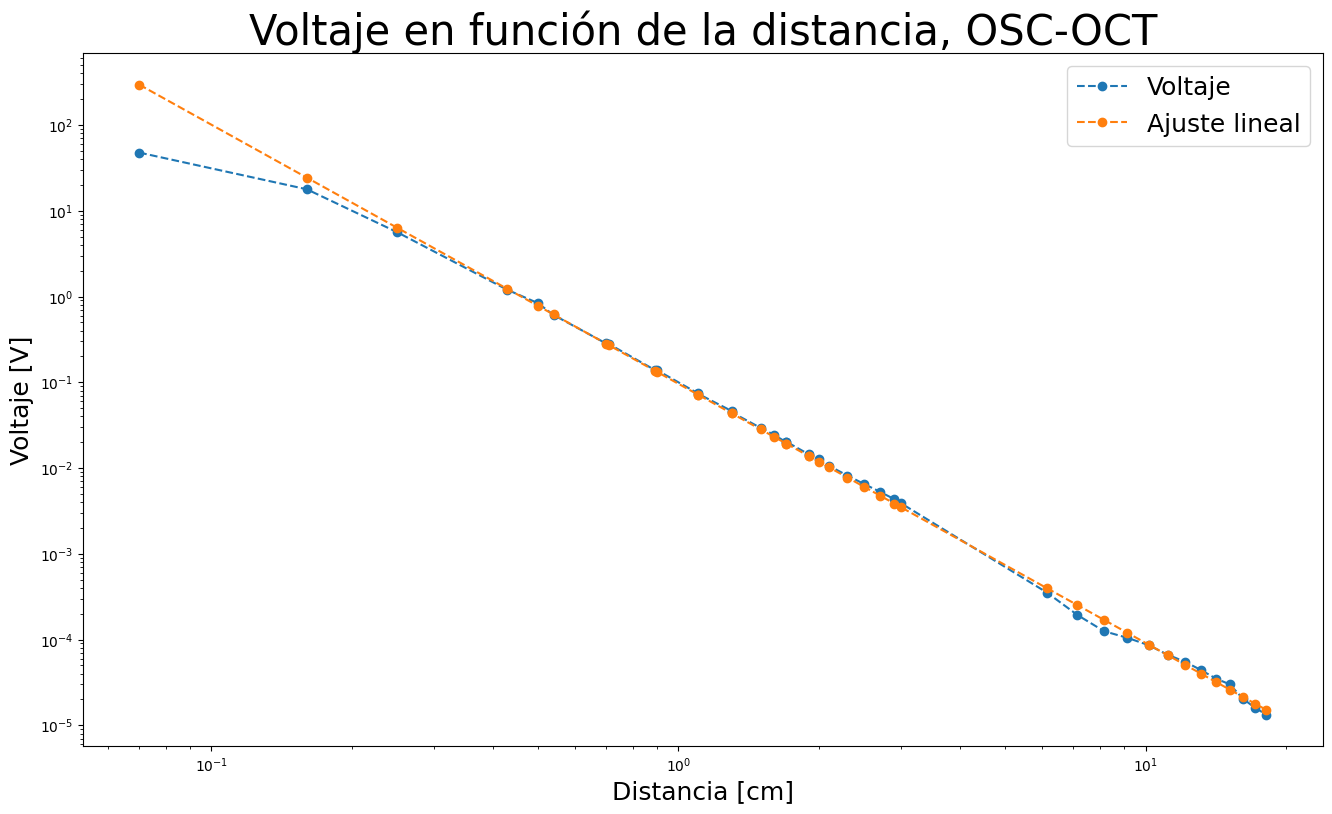

In [28]:
plt.figure(figsize=(16,9))
plt.loglog(din,Vin,'o--')
plt.loglog(din,B_short(din,*P,log=True),'o--')
plt.title('Voltaje en función de la distancia, OSC-OCT',fontsize=30)
plt.legend(['Voltaje','Ajuste lineal'],fontsize=18)

plt.xlabel('Distancia [cm]',fontsize=18)
plt.ylabel('Voltaje [V]',fontsize=18)

In [29]:
Vosclab=pd.concat([V1,V2,V3,V4[2:6]],ignore_index=True)
Vosclab=Vosclab.sort_values(by=['d'])
Vin=Vosclab['V'].to_numpy()
din=Vosclab['d'].to_numpy()

In [30]:
cutinf=1
cuthigh=len(Vin)
#n=8
# dtest=list(d[:n])+list(d[n+1:])
# vtest=list(V[:n])+list(V[n+1:])
P=np.polyfit(np.log(din[cutinf:cuthigh]),np.log(Vin[cutinf:cuthigh]),1)
# P=np.polyfit(np.log(dtest),np.log(vtest),1)

#P=np.polyfit(np.log(distd2[1:-1]),np.log(V2[1:-1]),1)
P

array([-2.9626641 , -2.34960121])

Text(0, 0.5, 'Voltaje [V]')

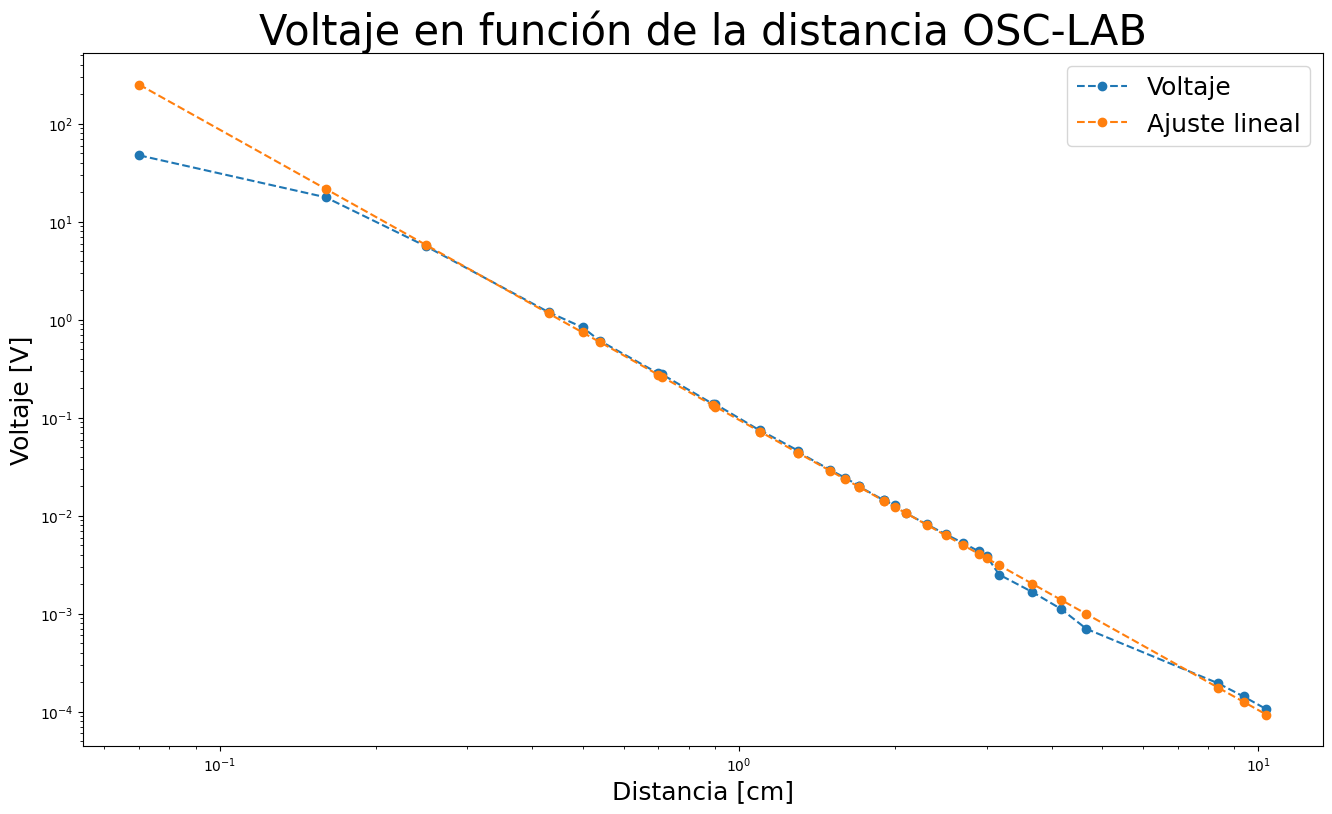

In [31]:
plt.figure(figsize=(16,9))
plt.loglog(din,Vin,'o--')
plt.loglog(din,B_short(din,*P,log=True),'o--')
plt.title('Voltaje en función de la distancia OSC-LAB',fontsize=30)
plt.legend(['Voltaje','Ajuste lineal'],fontsize=18)

plt.xlabel('Distancia [cm]',fontsize=18)
plt.ylabel('Voltaje [V]',fontsize=18)

In [32]:
Voscosc=pd.concat([V1,V2],ignore_index=True)
Voscosc=Voscosc.sort_values(by=['d'])
Vin=Voscosc['V'].to_numpy()
din=Voscosc['d'].to_numpy()


In [33]:
cutinf=2
cuthigh=len(Vin)
#n=8
# dtest=list(d[:n])+list(d[n+1:])
# vtest=list(V[:n])+list(V[n+1:])
P=np.polyfit(np.log(din[cutinf:cuthigh]),np.log(Vin[cutinf:cuthigh]),1)
# P=np.polyfit(np.log(dtest),np.log(vtest),1)

#P=np.polyfit(np.log(distd2[1:-1]),np.log(V2[1:-1]),1)
P

array([-2.9626779 , -2.31680096])

Text(0, 0.5, 'Voltaje [V]')

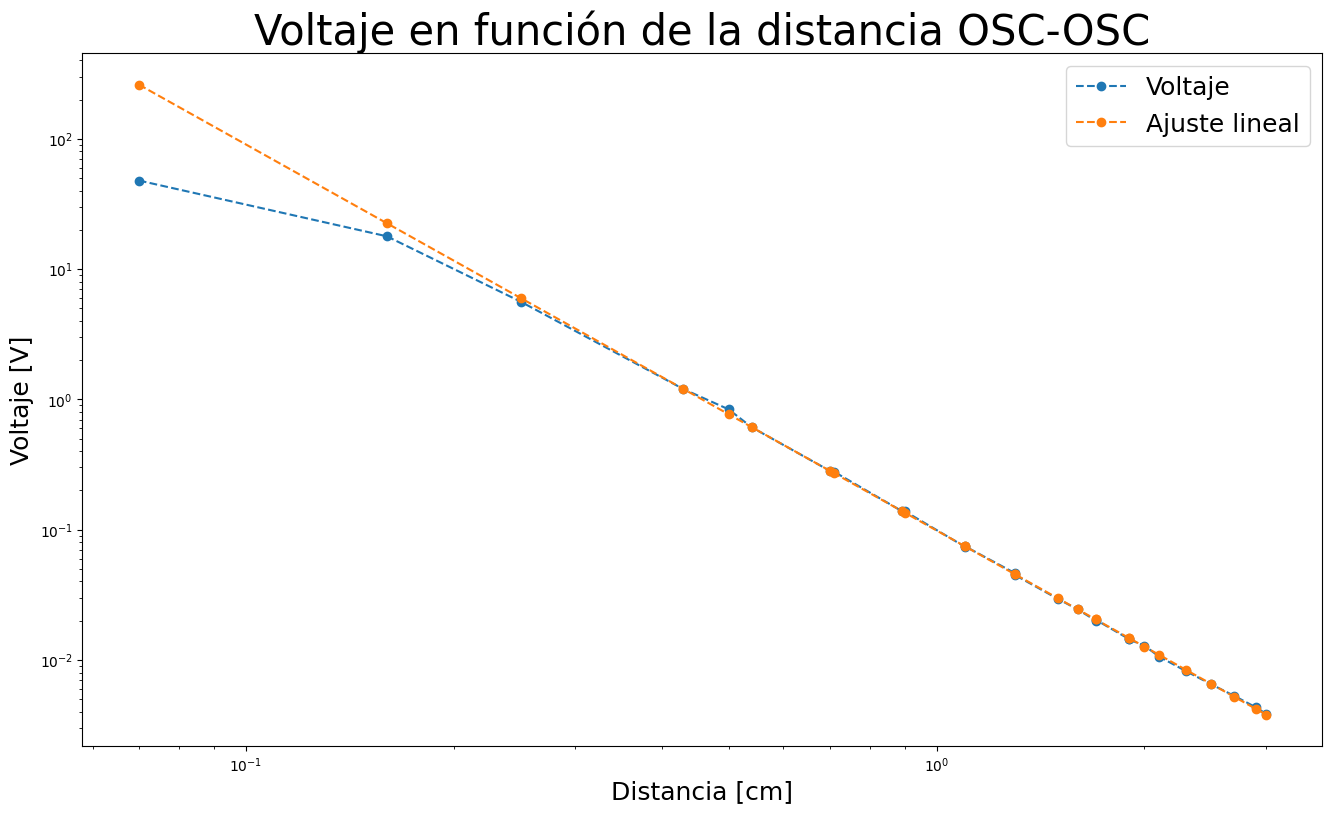

In [34]:
plt.figure(figsize=(16,9))
plt.loglog(din,Vin,'o--')
plt.loglog(din,B_short(din,*P,log=True),'o--')
plt.title('Voltaje en función de la distancia OSC-OSC',fontsize=30)
plt.legend(['Voltaje','Ajuste lineal'],fontsize=18)

plt.xlabel('Distancia [cm]',fontsize=18)
plt.ylabel('Voltaje [V]',fontsize=18)